# symbol2vec -- mapping string stock symbols into vector representations

In this notebook we take stock symbols and their log returns within a fixed time window and we use a SVD to find a vector representation of each stock symbol.
The intuitive reading is that stock symbols that move together are similar (same sector, market area) and so they should be mapped to more similar vectors.

The implementation uses a TruncatedSVD by scikit-learn to compute the stock symbol embedding.

In [19]:
import sys

sys.path.append("../..")

from datetime import date
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import polars as pl
from sklearn.decomposition import TruncatedSVD

from etl.transformation.silver.symbol_embeddings import load_log_returns, drop_incomplete_symbols

In [20]:
EMBEDDING_SIZE = 16

SEED = 16*29
DATAPLATFORM_ROOT = "../../dataplatform"


## Walkthrough

Read from the `silver.candles_daily` table and select only the columns `timeframe`, `symbol`, `log_return_1d`. We use returns instead of raw price, because prices have wide shifts in magnitude across symbols, while returns are more consistent; log-returns specifically for their symmetry around 0 and especially because they are additive (ie linear) over time ($lr_{t_1,t_2})=\sum_{t=t_1}^{t_2} lr_t$) which is a requirement for the SVD

In [21]:
lf = load_log_returns(DATAPLATFORM_ROOT, date(2021, 1, 1), date(2022, 1, 1))
df = drop_incomplete_symbols(lf).collect()
print(f"dataframe shape: {df.shape}")
df.head()

[15:46:28] Loading from disk data model candles_daily
[15:46:28] silver/candles_daily scan plan ready from disk
dataframe shape: (1631448, 3)


symbol,timeframe,log_return_1d
str,date,f64
"""MAN""",2021-01-14,0.023653
"""MAN""",2021-05-19,-0.005999
"""MAN""",2021-05-13,0.025006
"""MAN""",2021-01-11,-0.017562
"""MAN""",2021-05-28,-0.008887


Then we need to pivot the data: the matrix R constructed here is a matrix with one row per stock symbol $s$ and one column per selected date $d$. The value at $R_{s,d}$ is the 1 day log return registered for stock symbol $s$ at day $d$ (note this means specifically the return from starting price at day $d-1$ to day $d$).
Values are standardized first (zero mean and unit variance) on a per-symbol basis, meaning that the mean and variance used to standardize values of symbol $s$ are only computed from $s$' row

In [22]:
panel = df.pivot(on="timeframe", index="symbol", values="log_return_1d").sort("symbol")

# pivot doesn't guarantee chronological column order, so realign explicitly
day_columns = sorted(c for c in panel.columns if c != "symbol")
panel = panel.select(["symbol", *day_columns])

symbols = panel["symbol"].to_list()
R = panel.select(day_columns).to_numpy()
# standardize EACH SYMBOL's series (across time) so co-movement, not raw
# volatility, drives the factors -- correlation- rather than covariance-based.
# No NaNs survive drop_incomplete_symbols, so plain mean/std is enough.
R = (R - R.mean(axis=1, keepdims=True)) / (R.std(axis=1, keepdims=True) + 1e-8)
print(f"pivoted returns matrix shape: {R.shape}")

pivoted returns matrix shape: (6474, 252)


Compute symbol embeddings by SVD: let $R=U\Sigma V^T$ be the SVD of $R$, take the first `EMBEDDING_SIZE` columns of $U$ and the first `EMBEDDING_SIZE` columns/rows of $\Sigma$ and multiply them together. The result is a matrix with one row per symbol and exactly `EMBEDDING_SIZE` columns and each of these rows is the symbol embedding.

Why U is the symbol representation: symbol $s$'s entire return series is `R[s,:] = U[s,:] · Σ · Vᵀ`. That says symbol $s$'s series is a blend of the `k` factor time-patterns (rows of $V^T$), mixed with weights `U[i,:]·Σ`. Those mixing weights, "how much of each co-movement factor is in this stock", are the desired embedding

In [23]:
embeddings = TruncatedSVD(n_components=EMBEDDING_SIZE, random_state=SEED).fit_transform(R)
symbol_to_vec = dict(zip(symbols, embeddings))
embeddings.shape

(6474, 16)

If the embedding is doing its job, pairs of companies from the same sector (and therefore prone to moving together) should sit closer together in vector space than pairs from unrelated sectors. We spot-check three same-sector pairs -- Apple (AAPL) and Microsoft (MSFT) in big tech, Coca-Cola (KO) and PepsiCo (PEP) in soft drinks, and ExxonMobil (XOM) and Chevron (CVX) among the oil majors -- against two unrelated pairs, Apple vs ExxonMobil and Coca-Cola vs Nvidia (NVDA).

AAPL  vs MSFT  [big tech       ] cosine similarity = +0.954
KO    vs PEP   [soft drinks    ] cosine similarity = +0.902
XOM   vs CVX   [oil majors     ] cosine similarity = +0.990
AAPL  vs XOM   [tech vs oil    ] cosine similarity = +0.065
KO    vs NVDA  [staples vs semis] cosine similarity = +0.129


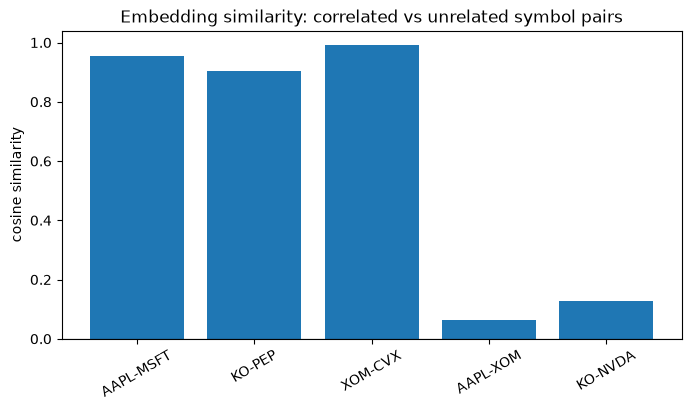

In [24]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# a few pairs with a well known sector relationship, used only as a sanity check
pairs = [
    ("AAPL", "MSFT", True, "big tech"),
    ("KO", "PEP", True, "soft drinks"),
    ("XOM", "CVX", True, "oil majors"),
    ("AAPL", "XOM", False, "tech vs oil"),
    ("KO", "NVDA", False, "staples vs semis"),
]

for a, b, expected_correlated, label in pairs:
    if a not in symbol_to_vec or b not in symbol_to_vec:
        print(f"skipping {a}/{b} ({label}): missing from embeddings")
        continue
    sim = cosine_similarity(symbol_to_vec[a], symbol_to_vec[b])
    print(f"{a:5s} vs {b:5s} [{label:15s}] cosine similarity = {sim:+.3f}")


available = [(a, b, label) for a, b, _, label in pairs if a in symbol_to_vec and b in symbol_to_vec]
sims = [cosine_similarity(symbol_to_vec[a], symbol_to_vec[b]) for a, b, _ in available]
labels = [f"{a}-{b}" for a, b, _ in available]

plt.figure(figsize=(8, 4))
plt.bar(labels, sims)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("cosine similarity")
plt.title("Embedding similarity: correlated vs unrelated symbol pairs")
plt.xticks(rotation=30)
plt.show()

Note in the graph above that Apple (AAPL) and Microsoft (MSFT), Coca-Cola (KO) and PepsiCo (PEP), and ExxonMobil (XOM) and Chevron (CVX) are all extremely similar -- every value is $\gt 0.9$, where $1$ is the maximum. The unrelated pairs behave the opposite way: Apple vs ExxonMobil and Coca-Cola vs Nvidia (NVDA) both sit close to $0$.

Mapping table `silver.symbol_embeddings` will have the following structure and allows to query it by the symbol string and get the list of float values corresponding to the symbol ordered embedding.

(Note that the actual stored table repeats this process on multiple time window and includes the `not_before` column which specifies when the embedding is allowed to be used safely without introducing lookahead bias in the model)

In [33]:
embedding_columns = {f"dim_{i}": embeddings[:, i] for i in range(EMBEDDING_SIZE)}
lookup = pl.DataFrame({"symbol": symbols, **embedding_columns})
lookup.head(n=10)

symbol,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""A""",-7.363868,5.443945,-4.609713,4.606599,-5.069266,0.147773,0.212899,-0.11634,0.733076,-0.432472,0.9913,-0.048082,-0.536827,-1.055921,-1.546557,-0.046653
"""AA""",-9.314764,-2.758562,3.627789,-3.444635,-0.487716,1.00083,2.504731,1.038473,0.268835,-0.144578,0.653504,1.357481,0.10427,-1.784586,-0.597686,0.147024
"""AAAU""",-3.116205,2.245559,-1.850638,-8.374003,-3.952507,-6.076286,-2.500293,2.686457,-5.956419,-2.074409,0.734289,0.284425,-0.506174,-0.208833,-0.207188,-0.029674
"""AACG""",-2.693067,0.755052,0.892406,2.089078,1.213658,1.586569,-1.223308,0.351646,2.46496,0.071607,-0.369324,-0.021276,1.005854,-0.085153,-1.390251,3.866287
"""AAGH""",1.518754,0.653301,2.890221,1.481113,3.438172,-7.486961,4.35866,2.221461,1.790641,1.272985,-1.758731,0.282545,0.639385,2.041234,0.812235,-2.042556
"""AAL""",-8.513527,-2.117672,3.619535,-2.188539,4.949948,1.910213,1.601029,-2.852066,-1.939642,-3.318964,1.16729,-1.268224,-0.197179,-1.139672,-0.80536,-2.174326
"""AAME""",-2.779842,3.601286,1.922342,-1.276675,0.939533,-3.045513,-1.880217,1.008233,0.923993,0.604055,0.918152,-0.574319,-0.521508,1.058577,1.38746,-1.93215
"""AAMI""",-9.598331,0.716971,-1.304655,1.954733,-2.692614,2.432115,-0.945261,-0.31768,0.128582,0.080918,-1.547819,-0.92922,-1.045579,-0.086785,0.135291,1.069847
"""AAMTF""",-0.001014,0.151273,2.658221,-0.133093,-0.638628,0.786005,-0.094941,2.080302,-0.902605,0.555898,-2.314155,-1.452125,0.581607,2.31212,1.237316,-0.827707


## Embedding rotation

We now repeat the same experiment but with a different time window for return data. SVD factors are only defined up to sign flip and rotation (in case singular values are close). The first component of the embedding of the same symbol $s$ may appear positively in one of the embedding matrix and negative in the other and its also possible for the embedding vector to be rotated.
With this new embedding computed from a different time window we'll show a few examples where this shows up, motivating the use of `orthogonal_procrustes` to realign embedding matrices across time frames

In [26]:
from scipy.linalg import orthogonal_procrustes

# Window 1 is the walkthrough window (2021-01 .. 2022-01); we reuse its results.
# Window 2 is shifted forward and OVERLAPS window 1, so genuine co-movement
# structure is largely shared and the leftover disagreement is mostly the SVD
# basis artifact (sign flip / rotation) -- for symbols with real factor loadings.
WINDOW_2 = (date(2021, 7, 1), date(2022, 7, 1))


def build_window_embedding(start: date, end: date):
    """Repeat the walkthrough pipeline (load -> pivot -> standardize -> SVD) for one window."""
    lf = load_log_returns(DATAPLATFORM_ROOT, start, end)
    df_w = drop_incomplete_symbols(lf).collect()

    panel_w = df_w.pivot(on="timeframe", index="symbol", values="log_return_1d").sort("symbol")
    day_cols = sorted(c for c in panel_w.columns if c != "symbol")
    panel_w = panel_w.select(["symbol", *day_cols])

    syms = panel_w["symbol"].to_list()
    Rw = panel_w.select(day_cols).to_numpy()
    Rw = (Rw - Rw.mean(axis=1, keepdims=True)) / (Rw.std(axis=1, keepdims=True) + 1e-8)

    emb = TruncatedSVD(n_components=EMBEDDING_SIZE, random_state=SEED).fit_transform(Rw)
    return syms, emb


def row_cosine(P: np.ndarray, Q: np.ndarray) -> np.ndarray:
    """Row-wise cosine similarity, NaN where either vector has ~zero norm."""
    denom = np.linalg.norm(P, axis=1) * np.linalg.norm(Q, axis=1)
    num = np.sum(P * Q, axis=1)
    out = np.full(len(P), np.nan)
    ok = denom > 1e-12
    out[ok] = num[ok] / denom[ok]
    return out


# window 1: reuse the walkthrough results; window 2: newly derived
symbols_1, emb_1 = symbols, embeddings
symbols_2, emb_2 = build_window_embedding(*WINDOW_2)

# line up the embedding matrixes with the same order for symbol's rows
idx1 = {s: i for i, s in enumerate(symbols_1)}
idx2 = {s: i for i, s in enumerate(symbols_2)}
shared = sorted(set(idx1) & set(idx2))
A = np.stack([emb_1[idx1[s]] for s in shared])  # reference frame (window 1)
B = np.stack([emb_2[idx2[s]] for s in shared])  # window 2, to be aligned

print(A.shape)
print(B.shape)

[15:46:29] Loading from disk data model candles_daily
[15:46:29] silver/candles_daily scan plan ready from disk
(6467, 16)
(6467, 16)


In [27]:
# A symbol's embedding norm = how strongly it loads on the retained factors.
# Near-zero-norm rows are illiquid / idiosyncratic names that co-move with nothing;
# their embeddings are essentially noise, so cosine is undefined (NaN) or meaningless,
# AND a single global rotation cannot fix them. Restrict diagnostics to real loaders.
norm1, norm2 = np.linalg.norm(A, axis=1), np.linalg.norm(B, axis=1)
high_snr = (norm1 > np.median(norm1)) & (norm2 > np.median(norm2))

raw_self = row_cosine(A, B)
print(f"{len(shared)} shared symbols; {int(high_snr.sum())} above-median-norm (high-SNR)")
print(f"mean raw self-similarity   all: {np.nanmean(raw_self):+.3f}"
      f"    high-SNR only: {np.nanmean(raw_self[high_snr]):+.3f}")

# demonstrate on interpretable high-SNR names (the section-1 set), not on the
# worst-misaligned outliers -- those are noise Procrustes provably can't rotate away.
demo_symbols = [s for s in ["AAPL", "MSFT", "KO", "PEP", "XOM", "CVX", "NVDA"] if s in idx1 and s in idx2]
pos = {s: i for i, s in enumerate(shared)}
print("\nraw self-similarity on well-known high-SNR names:")
for s in demo_symbols:
    print(f"  {s:5s} cosine(win1, win2) = {raw_self[pos[s]]:+.3f}")

6467 shared symbols; 2788 above-median-norm (high-SNR)
mean raw self-similarity   all: +0.446    high-SNR only: +0.620

raw self-similarity on well-known high-SNR names:
  AAPL  cosine(win1, win2) = +0.400
  MSFT  cosine(win1, win2) = +0.357
  KO    cosine(win1, win2) = +0.211
  PEP   cosine(win1, win2) = -0.100
  XOM   cosine(win1, win2) = +0.223
  CVX   cosine(win1, win2) = +0.404
  NVDA  cosine(win1, win2) = +0.691


The raw self-similarities are low even though these are the *same companies* over two overlapping windows. That cannot be a real change in the business, it is the coordinate system moving. Each `TruncatedSVD` run picks its own axes, defined only up to sign flips and (when singular values are close) rotations among components, so window 2's "factor 3" is not window 1's "factor 3" and a raw component-by-component comparison is meaningless.

Two cautions this notebook learned the hard way, both about *which symbols* to trust:

- **Zero-norm embeddings are noise.** A symbol whose standardized returns barely project onto any retained factor gets an embedding near the origin; its cosine is undefined (`NaN`) and poisons any average. We restrict the diagnostics to above-median-norm names.
- **The artifact is global, so measure it on strong loaders.** `orthogonal_procrustes` finds the single orthogonal $\Omega$ (rotation + reflection, distance- and angle-preserving) that best maps window 2 onto window 1. It can only remove the rotation *shared by all symbols*; whatever is left per symbol is genuine drift plus idiosyncratic noise. High-SNR names (strong factor loadings) are dominated by the shared rotation, so they recover after alignment; illiquid outliers are dominated by their own noise and do not, which is why we demonstrate on the section-1 names, not on the worst-misaligned tickers.

Frobenius || win2 - win1 ||        before:    713.2    after:    479.5
mean self-similarity (high-SNR)    before: +0.620    after: +0.878


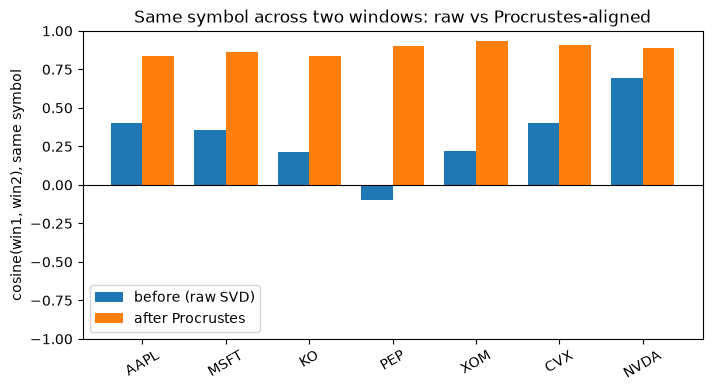

In [28]:
# one orthogonal transform that best maps ALL of window 2 onto window 1
omega, _ = orthogonal_procrustes(B, A)   # minimizes || B @ omega - A ||_F

B_aligned = B @ omega
emb_2_aligned = emb_2 @ omega            # apply to the WHOLE window-2 embedding, not just shared rows
aligned_self = row_cosine(A, B_aligned)

# aggregate evidence: the global rotation is removed across the whole universe
print(f"Frobenius || win2 - win1 ||        before: {np.linalg.norm(B - A):8.1f}"
      f"    after: {np.linalg.norm(B_aligned - A):8.1f}")
print(f"mean self-similarity (high-SNR)    before: {np.nanmean(raw_self[high_snr]):+.3f}"
      f"    after: {np.nanmean(aligned_self[high_snr]):+.3f}")

# per-symbol view on the interpretable high-SNR names
sel = [pos[s] for s in demo_symbols]
before, after = raw_self[sel], aligned_self[sel]

x = np.arange(len(demo_symbols))
width = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, before, width, label="before (raw SVD)")
plt.bar(x + width / 2, after, width, label="after Procrustes")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("cosine(win1, win2), same symbol")
plt.title("Same symbol across two windows: raw vs Procrustes-aligned")
plt.xticks(x, demo_symbols, rotation=30)
plt.ylim(-1, 1)
plt.legend()
plt.show()

After alignment the high-SNR names line up with themselves and the high-SNR aggregate jumps toward 1, while the Frobenius distance over *all* shared symbols also drops sharply -- that global drop is the rotation being stripped out across the whole universe, even though noisy tickers individually don't reflect it. Two things worth keeping in mind:

- **The residual is not zero, and that is correct.** What survives alignment is genuine drift in a company's co-movement structure between the two windows, plus estimation noise. Orthogonal Procrustes removes only the arbitrary basis orientation and deliberately leaves real change in place, ie the signal a time-varying embedding is meant to carry. Shrinking `TIME_SHIFT` (more overlap) reduces genuine drift and makes the recovery visibly cleaner.
- **Reference frame and chaining.** Window 1 is the anchor and `emb_2_aligned` is what you would persist for window 2. Across many periods, align each window to the previous one (or all to a common anchor) so every stored embedding shares one coordinate system -- the precondition for feeding embeddings from different periods into the same downstream model.

### What alignment cannot fix

For contrast we now mark a handful of *low-SNR* symbols -- names with small embedding norm in **both** windows, i.e. weak loadings on the common factors. Their cross-window difference is dominated by idiosyncratic noise, not the shared basis rotation, so the single orthogonal $\Omega$ that rescued the high-SNR names has little to grip: it should improve these far less, if at all. This is the flip side of the earlier caveat -- Procrustes removes the *global* artifact, never per-symbol noise.

1209 low-SNR shared symbols (bottom-quartile norm in both windows)
mean self-similarity (low-SNR)     before: +0.110    after: +0.327
mean self-similarity (high-SNR)    before: +0.620    after: +0.878   <- for contrast

illustrative low-SNR symbols left behind by alignment:
  MSEXP  norm(win1,win2)=(1.83, 1.83)  cosine before=+0.322  after=+0.781
  KNDYF  norm(win1,win2)=(1.78, 1.99)  cosine before=+0.502  after=+0.547
  RSMDF  norm(win1,win2)=(1.69, 2.19)  cosine before=+0.198  after=+0.115
  GBCS   norm(win1,win2)=(2.23, 1.76)  cosine before=+0.169  after=+0.198
  ZTSTF  norm(win1,win2)=(2.05, 2.06)  cosine before=+0.387  after=+0.575
  INPAP  norm(win1,win2)=(1.84, 2.29)  cosine before=+0.218  after=+0.654
  IVT    norm(win1,win2)=(2.23, 1.96)  cosine before=+0.114  after=+0.664


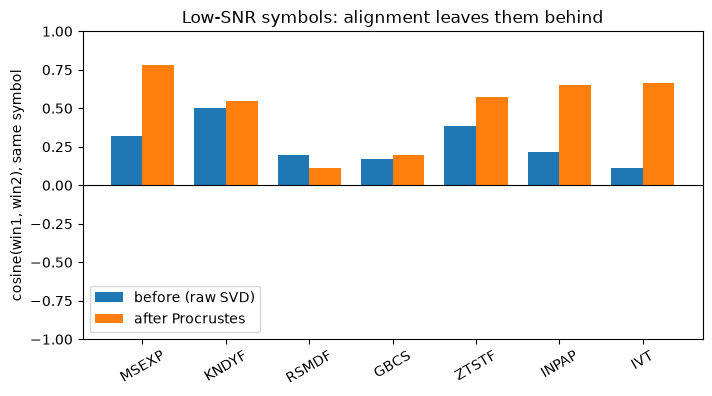

In [29]:
# low-SNR: weak loaders (bottom-quartile norm in BOTH windows), with a defined cosine to plot
low_snr = (norm1 < np.quantile(norm1, 0.25)) & (norm2 < np.quantile(norm2, 0.25))
finite = np.isfinite(raw_self) & np.isfinite(aligned_self)
cand = np.where(low_snr & finite)[0]

# most extreme (smallest combined norm) as the illustrative "left behind" set
weak_idx = cand[np.argsort(norm1[cand] + norm2[cand])][:7]
weak_symbols = [shared[i] for i in weak_idx]

print(f"{int(low_snr.sum())} low-SNR shared symbols (bottom-quartile norm in both windows)")
print(f"mean self-similarity (low-SNR)     before: {np.nanmean(raw_self[low_snr]):+.3f}"
      f"    after: {np.nanmean(aligned_self[low_snr]):+.3f}")
print(f"mean self-similarity (high-SNR)    before: {np.nanmean(raw_self[high_snr]):+.3f}"
      f"    after: {np.nanmean(aligned_self[high_snr]):+.3f}   <- for contrast\n")
print("illustrative low-SNR symbols left behind by alignment:")
for i in weak_idx:
    print(f"  {shared[i]:6s} norm(win1,win2)=({norm1[i]:.2f}, {norm2[i]:.2f})  "
          f"cosine before={raw_self[i]:+.3f}  after={aligned_self[i]:+.3f}")

before_w, after_w = raw_self[weak_idx], aligned_self[weak_idx]

x = np.arange(len(weak_symbols))
width = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, before_w, width, label="before (raw SVD)")
plt.bar(x + width / 2, after_w, width, label="after Procrustes")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("cosine(win1, win2), same symbol")
plt.title("Low-SNR symbols: alignment leaves them behind")
plt.xticks(x, weak_symbols, rotation=30)
plt.ylim(-1, 1)
plt.legend()
plt.show()